### Rolling median calculation

Detecting anomalous prices requires a method that judges each price relative to what is normal for that hour  rather than against a single market-wide standard. A hard threshold of, say, a `$200/MWh` and a fixed percentile cutoff strip away this context, since neither provides a local baseline. A flat dollar threshold ignores the prevailing regime: `$200/MWh` is a dramatic deviation in a month where the hour normally clears at `$50/MWh`, but unremarkable in a month where it normally clears at `$180/MWh`. A global percentile of the raw prices has the opposite problem, it simply selects the highest-priced hours across the whole sample, flagging expensive hours rather than anomalous ones.

An earlier observation motivates the alternative: there is strong structure between hour-of-day and price, and for the most part, prices behave normally within each hour, with only a small set of hours behaving as outliers. We use this to construct a per-hour baseline.

Each price is therefore normalized against what is normal for that specific hour. The median is preferred over the mean for the baseline, so that the reference level is itself robust to the outliers we are trying to detect. For each observation $i$ (grouped by hour-of-day), the baseline is the median of the 30 preceding observations, with the current observation excluded, so the score never depends on the point being judged:
$$
\tilde{m}_i = \operatorname{median}\{x_{i-30}, \ldots, x_{i-1}\}
$$
giving a residual $r_i = x_i - \tilde{m}_i$.

To judge whether a deviation is meaningful, we compare its size to the hour's normal movement using the median of the prior 30 absolute residuals:
$$
\text{MAD}_i = \operatorname{median}\{\,|r_{i-30}|, \ldots, |r_{i-1}|\,\}
$$
This measures the move against how tightly the hour has recently behaved. The final robust score is
$$
z_i = \frac{r_i}{\max(\text{MAD}_i,\ 1)}
$$
where the denominator is floored at `1/MWh` to prevent the score from exploding during flat stretches when recent residuals are near zero. This score is a *relative, per-hour-normalized* measure of how far an hour sits from its own recent baseline, that is, a larger score means a more pronounced departure, so it is used to rank and flag hours, not to quantify the size of an event. Empirically the distribution is heavily right-skewed which is why the score is treated as a relative ranking rather than a calibrated magnitude.

The window spans the 28 most recent prior observations for each hour-of-day, approximately one month of trailing history, to balance two competing needs: a window long enough for the median to rest on a stable set of observations, and short enough that the baseline tracks the substantial shifts in price level over time rather than lagging them.

In [94]:
import pandas as pd
import duckdb as ddb
import matplotlib.pyplot as plt
import numpy as np

ActualForecast = pd.read_csv('ActualForecastData.csv', parse_dates=['date_he'])
backfill = pd.read_csv('backfill_2022_clean.csv', parse_dates=['date_he'])

ActualForecast = (
    pd.concat([backfill, ActualForecast], ignore_index=True)
    .drop_duplicates('date_he')      # in case backfill and main overlap at the seam
    .sort_values('date_he')
    .reset_index(drop=True)
)

print("rows:", len(ActualForecast))
print("range:", ActualForecast['date_he'].min(), "->", ActualForecast['date_he'].max())
print("date_he unique:", ActualForecast['date_he'].is_unique)

gap = ActualForecast['date_he'].diff().max()
print("largest gap:", gap)
print("gaps over 1h:", (ActualForecast['date_he'].diff() > pd.Timedelta('1h')).sum())

d = ActualForecast['date_he'].diff()
gaps = ActualForecast.loc[d > pd.Timedelta('1h'), ['date_he']].copy()
gaps['gap'] = d[d > pd.Timedelta('1h')]
gaps['prev'] = gaps['date_he'] - gaps['gap']
print(gaps[['prev', 'date_he', 'gap']].to_string(index=False))

d = ActualForecast['date_he'].diff()
print((d > pd.Timedelta('1h')).sum(), "gaps > 1h")
print(d[d > pd.Timedelta('1h')])   # full list, no truncation

bf = ActualForecast[ActualForecast['date_he'] < '2023-01-01']
print(bf.groupby(bf['date_he'].dt.hour).size().min(), "min obs per hour")

rows: 31580
range: 2022-11-01 01:00:00 -> 2026-06-09 00:00:00
date_he unique: True
largest gap: 0 days 02:00:00
gaps over 1h: 4
               prev             date_he             gap
2023-03-12 01:00:00 2023-03-12 03:00:00 0 days 02:00:00
2024-03-10 01:00:00 2024-03-10 03:00:00 0 days 02:00:00
2025-03-09 01:00:00 2025-03-09 03:00:00 0 days 02:00:00
2026-03-08 01:00:00 2026-03-08 03:00:00 0 days 02:00:00
4 gaps > 1h
3145    0 days 02:00:00
11880   0 days 02:00:00
20615   0 days 02:00:00
29350   0 days 02:00:00
Name: date_he, dtype: timedelta64[us]
60 min obs per hour


In [95]:
price_rolling_median = ddb.sql('''
    with roll_window as (
        select
            date_he,
            actual_price,
            row_number() over (
                partition by hour(date_he) order by date_he
                ) as rn,  -- per-hour counter
            quantile_cont(actual_price, 0.5) over (
                partition by hour(date_he)
                order by date_he
                rows between 28 preceding and 1 preceding --rolling window, not including the current value
                ) as same_hour_28_obs_roll_med,
            ((forecast_ail - actual_ail)/actual_ail)*100 as demand_pct_error
        from ActualForecast
    ),
    roll_MAD as (
        select
            *,
            quantile_cont(abs(actual_price - same_hour_28_obs_roll_med), 0.5) over (
                partition by hour(date_he)
                order by date_he
                rows between 28 preceding and 1 preceding
            ) as same_hour_28_obs_roll_MAD -- median absolute deviation
        from roll_window
    )
    select
        date_he,
        actual_price,
        same_hour_28_obs_roll_med,
        same_hour_28_obs_roll_MAD,
        case
            when same_hour_28_obs_roll_MAD < 1.0
                then (actual_price - same_hour_28_obs_roll_med) / 1.0
            else (actual_price - same_hour_28_obs_roll_med) / same_hour_28_obs_roll_MAD
        end as median_deviation_score,
        demand_pct_error
    from roll_MAD
    where date_he >= '2023-01-01'
    order by date_he
    ''').df()

# Check that the rolling median is computed correctly
check_med = ActualForecast[['date_he', 'actual_price']].copy()

check_med['roll_med'] = (
    ActualForecast
    .groupby(ActualForecast['date_he'].dt.hour)['actual_price']
    .transform(lambda s: s.shift(1).rolling(28).median()) # preserve original df while adding new column
)
check_med = check_med[check_med['date_he'] >= '2023-01-01']
a = price_rolling_median.set_index('date_he')['same_hour_28_obs_roll_med']
b = check_med.set_index('date_he')['roll_med'].dropna()

# 1. Indexes must be unique, or alignment fans out / misbehaves
print("a index unique:", a.index.is_unique)
print("b index unique:", b.index.is_unique)

# 2. How many labels actually overlap? (this is what gets compared)
print("overlap:", a.index.intersection(b.index).size)
print("a only:", a.index.difference(b.index).size)
print("b only:", b.index.difference(a.index).size)

diff = (a - b).abs()
print("non-NaN comparisons:", diff.notna().sum())
print("max abs diff:", diff.max())


# Check MAD is computed correctly
check_MAD = ActualForecast[['date_he', 'actual_price']].copy()
check_MAD['roll_med'] = check_med['roll_med']
check_MAD['abs_resid'] = (check_MAD['actual_price'] - check_MAD['roll_med']).abs()
check_MAD['roll_MAD'] = (
    check_MAD
    .groupby(ActualForecast['date_he'].dt.hour)['abs_resid']
    .transform(lambda s: s.shift(1).rolling(28).median())
)
check_MAD = check_MAD[check_MAD['date_he'] >= '2023-01-01']

c = price_rolling_median.set_index('date_he')['same_hour_28_obs_roll_MAD']
d = check_MAD.set_index('date_he')['roll_MAD'].dropna()

# 1. Indexes must be unique, or alignment fans out / misbehaves
print("c index unique:", c.index.is_unique)
print("d index unique:", d.index.is_unique)

# 2. How many labels actually overlap? (this is what gets compared)
print("overlap:", c.index.intersection(d.index).size)
print("c only:", c.index.difference(d.index).size)
print("d only:", d.index.difference(c.index).size)

diff_mad = (c - d).abs()
print("non-NaN comparisons:", diff_mad.notna().sum())
print("max abs diff:", diff_mad.max())

print(price_rolling_median.info())
print(price_rolling_median.head())
print(price_rolling_median.tail())

a index unique: True
b index unique: True
overlap: 30117
a only: 0
b only: 0
non-NaN comparisons: 30117
max abs diff: 0.0
c index unique: True
d index unique: True
overlap: 29445
c only: 672
d only: 0
non-NaN comparisons: 29445
max abs diff: 0.0
<class 'pandas.DataFrame'>
RangeIndex: 30117 entries, 0 to 30116
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date_he                    30117 non-null  datetime64[us]
 1   actual_price               30117 non-null  float64       
 2   same_hour_28_obs_roll_med  30117 non-null  float64       
 3   same_hour_28_obs_roll_MAD  30117 non-null  float64       
 4   median_deviation_score     30117 non-null  float64       
 5   demand_pct_error           30117 non-null  float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 1.4 MB
None
              date_he  actual_price  same_hour_28_obs_roll_med  \
0 2023-01-01 00:00:00  

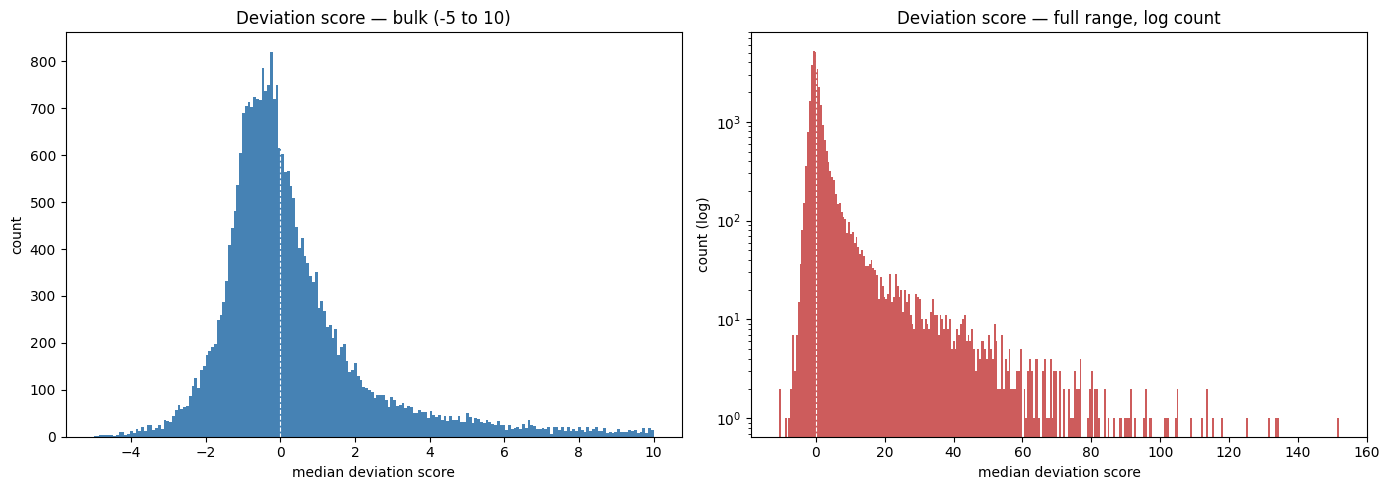

count    30117.000000
mean         1.721816
std          7.726891
min        -10.678899
25%         -0.839867
50%         -0.078439
75%          1.213488
max        151.937767
Name: median_deviation_score, dtype: float64
skew: 6.86 | kurtosis: 65.25
0.500    -0.08
0.900     4.72
0.950    10.53
0.975    21.42
0.990    39.75
0.999    86.50
Name: median_deviation_score, dtype: float64
max: 151.9
floored share: 0.0 %
floored share among score>5: 0.0 %


In [96]:
s = price_rolling_median['median_deviation_score'].dropna()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Left: the bulk — zoom to where normal hours live, linear y
ax[0].hist(s, bins=200, range=(-5, 10), color='steelblue', edgecolor='none')
ax[0].axvline(0, color='white', lw=0.8, ls='--')   # no-deviation line
ax[0].set_title('Deviation score — bulk (-5 to 10)')
ax[0].set_xlabel('median deviation score')
ax[0].set_ylabel('count')

# Right: full range, log y — so the spike tail is visible
ax[1].hist(s, bins=300, color='indianred', edgecolor='none')
ax[1].set_yscale('log')
ax[1].axvline(0, color='white', lw=0.8, ls='--')
ax[1].set_title('Deviation score — full range, log count')
ax[1].set_xlabel('median deviation score')
ax[1].set_ylabel('count (log)')

plt.tight_layout()
plt.show()

# quantify what the plot is showing
print(s.describe())
print("skew:", round(s.skew(), 2), "| kurtosis:", round(s.kurtosis(), 2))
print(s.quantile([.5, .9, .95, .975, .99, .999]).round(2))
print("max:", round(s.max(), 1))

floored = price_rolling_median['same_hour_28_obs_roll_MAD'] < 1.0
print("floored share:", round(floored.mean()*100, 2), "%")
print("floored share among score>5:", round(floored[price_rolling_median['median_deviation_score']>5].mean()*100, 2), "%")

In [97]:
from IPython.display import Markdown, display

q = s.quantile([.25, .75, .9, .95, .99])

para = (
    f"The bulk of the deviation score is centered near zero (median {s.median():.2f}), "
    f"but the mean sits at {s.mean():.2f}, showing the pull of the upper tail on the average. "
    f"The standard deviation is {s.std():.2f}, yet the middle 50% of scores span only about "
    f"{q[.25]:.2f} to {q[.75]:.2f}, far tighter than the std suggests. "
    f"This reflects that most hours sit close to their hour-of-day baseline; the std is inflated "
    f"by a thin set of extreme positive scores rather than describing a typical hour. "
    f"A skew of {s.skew():.2f} and kurtosis of {s.kurtosis():.2f} confirm a distribution that is "
    f"heavily right-skewed with a fat tail. The tail's reach is visible in the upper quantiles: "
    f"the 90th percentile is {q[.9]:.2f}, the 95th jumps to {q[.95]:.2f}, and the 99th to {q[.99]:.2f}."
)

display(Markdown(para))

The bulk of the deviation score is centered near zero (median -0.08), but the mean sits at 1.72, showing the pull of the upper tail on the average. The standard deviation is 7.73, yet the middle 50% of scores span only about -0.84 to 1.21, far tighter than the std suggests. This reflects that most hours sit close to their hour-of-day baseline; the std is inflated by a thin set of extreme positive scores rather than describing a typical hour. A skew of 6.86 and kurtosis of 65.25 confirm a distribution that is heavily right-skewed with a fat tail. The tail's reach is visible in the upper quantiles: the 90th percentile is 4.72, the 95th jumps to 10.53, and the 99th to 39.75.

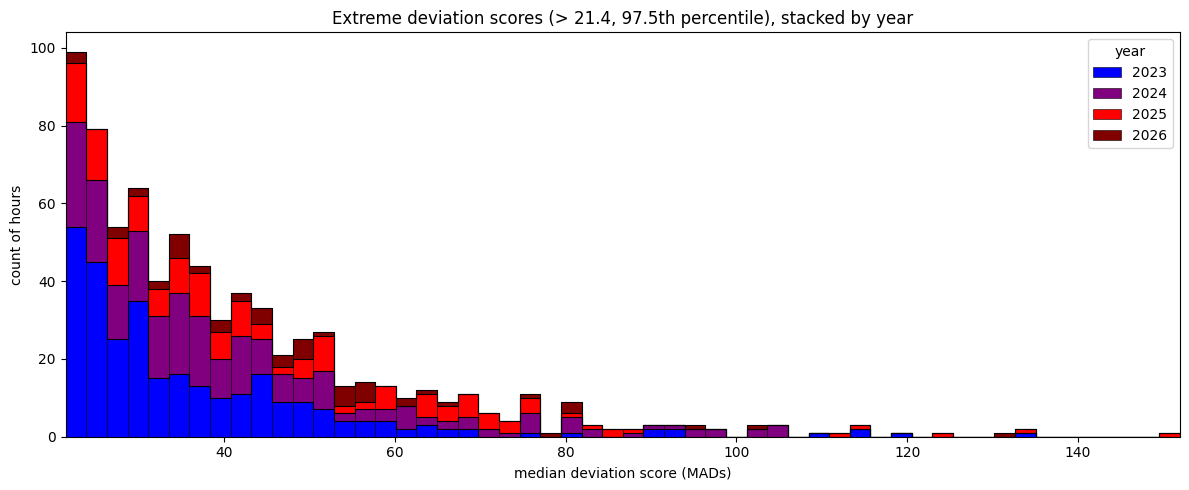

P97.5 cutoff: 21.42  |  total extreme hours: 753

by year:
year
2023    297
2024    239
2025    159
2026     58
Name: count, dtype: int64


In [98]:
p975 = price_rolling_median['median_deviation_score'].quantile(0.975)

tail = price_rolling_median.loc[
    price_rolling_median['median_deviation_score'] > p975,
    ['date_he', 'median_deviation_score']
].copy()
tail['year']  = tail['date_he'].dt.year

lo, hi = tail['median_deviation_score'].min(), tail['median_deviation_score'].max()
bins = np.linspace(lo, hi, 55)

# --- year graph (only plot kept) ---
year_colors = {2023: 'blue', 2024: 'purple', 2025: 'red', 2026: 'maroon'}
years = sorted(tail['year'].unique())
data_by_year = [tail.loc[tail['year'] == y, 'median_deviation_score'].values for y in years]

fig, ax = plt.subplots(figsize=(12, 5))
counts_y, edges, _ = ax.hist(
    data_by_year, bins=bins, stacked=True,
    color=[year_colors[y] for y in years], label=[str(y) for y in years],
    edgecolor='black', linewidth=0.4
)
for row in np.atleast_2d(counts_y):
    ax.step(edges, np.append(row, row[-1]), where='post', color='black', lw=0.8)
ax.set_xlim(lo, hi)
ax.set_title(f'Extreme deviation scores (> {p975:.1f}, 97.5th percentile), stacked by year')
ax.set_xlabel('median deviation score (MADs)')
ax.set_ylabel('count of hours')
ax.legend(title='year')
plt.tight_layout()
plt.show()

print(f"P97.5 cutoff: {p975:.2f}  |  total extreme hours: {len(tail)}")
print("\nby year:")
print(tail['year'].value_counts().sort_index())

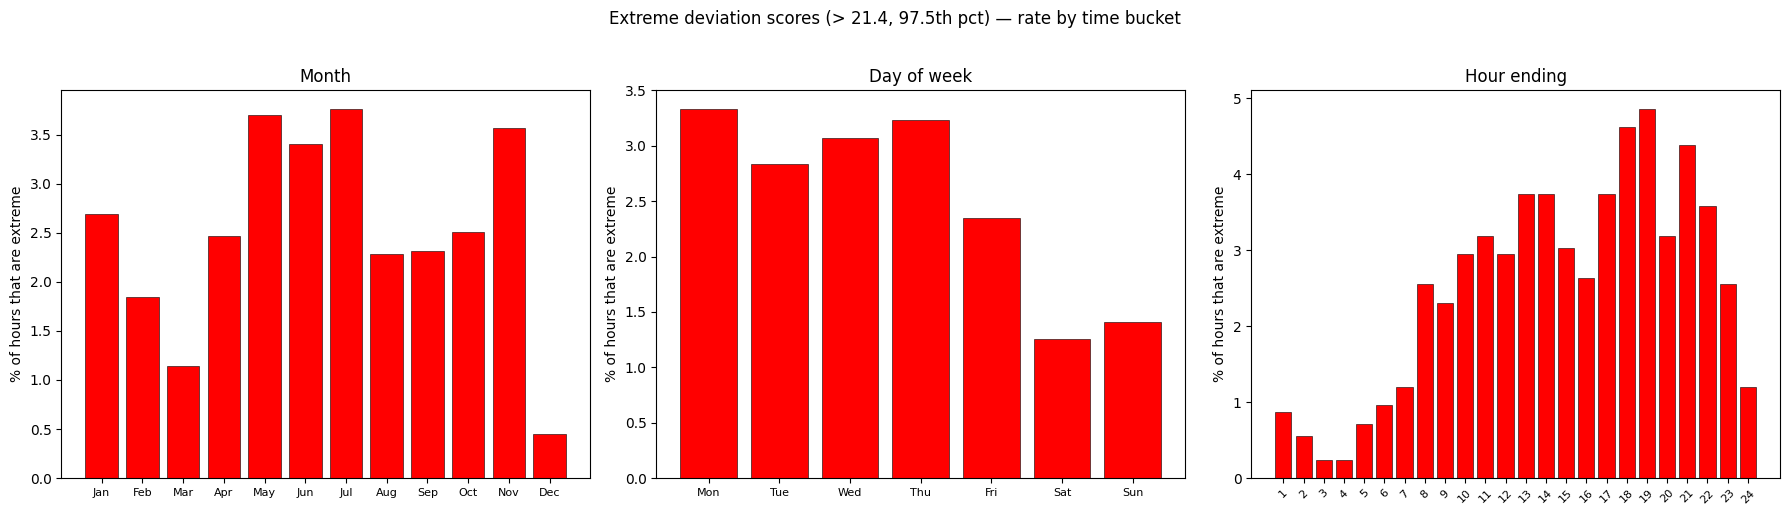

In [99]:
RATE = True   # True = extreme hours / total hours in bucket; False = raw counts

p975 = price_rolling_median['median_deviation_score'].quantile(0.975)
df = price_rolling_median.copy()
df['is_ext'] = df['median_deviation_score'] > p975

df['month'] = df['date_he'].dt.month
df['dow']   = df['date_he'].dt.dayofweek
df['he']    = df['date_he'].dt.hour.replace(0, 24)   # hour-ending: 0 -> 24

dims = [
    ('month', 'Month',       list(range(1, 13)),
        ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']),
    ('dow',   'Day of week', list(range(7)), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']),
    ('he',    'Hour ending', list(range(1, 25)), None),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, title, order, labels) in zip(axes, dims):
    ext   = df.loc[df['is_ext'], col].value_counts().reindex(order, fill_value=0)
    total = df[col].value_counts().reindex(order, fill_value=0)
    y = (ext / total * 100) if RATE else ext
    ax.bar(range(len(order)), y.values, color='red', edgecolor='black', linewidth=0.4)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(labels if labels else order,
                       rotation=45 if col == 'he' else 0, fontsize=8)
    ax.set_title(title)
    ax.set_ylabel('% of hours that are extreme' if RATE else 'count of extreme hours')

fig.suptitle(f'Extreme deviation scores (> {p975:.1f}, 97.5th pct) — '
             f'{"rate" if RATE else "count"} by time bucket', y=1.02)
plt.tight_layout()
plt.show()

In [100]:
p975 = price_rolling_median['median_deviation_score'].quantile(0.975)

tail = price_rolling_median.loc[
    price_rolling_median['median_deviation_score'] > p975
].copy().sort_values('median_deviation_score', ascending=False)

prices = tail['actual_price']

# --- 1. summary stats of the extreme-hour prices ---
print(f"P97.5 score cutoff: {p975:.2f}  |  extreme hours: {len(tail)}\n")
print("actual_price of extreme hours:")
print(prices.describe().round(2))
print("\nquantiles:")
print(prices.quantile([.5, .9, .95, .99]).round(2))

P97.5 score cutoff: 21.42  |  extreme hours: 753

actual_price of extreme hours:
count    753.00
mean     621.57
std      230.17
min       99.76
25%      441.72
50%      620.71
75%      812.72
max      999.99
Name: actual_price, dtype: float64

quantiles:
0.50    620.71
0.90    951.70
0.95    998.83
0.99    999.99
Name: actual_price, dtype: float64
